# 22DM015 Final Project — Financial PhraseBank
## Part 1 — Setting Up the Problem (1.5 pts)

**Dataset:** `takala/financial_phrasebank`, config `sentences_allagree` (2,264 sentences).  
**Labels:** 0 = negative, 1 = neutral, 2 = positive.

### Shared data contract (set by Person D — do NOT re-split)
- Evaluate on **`test`** only; tune on **`val`**. Use `eval_utils.evaluate` for consistency across notebooks.
- Log every result with `eval_utils.log_result(...)` into `results/results.csv`.

> **AI disclosure:** AI-generated code in this notebook carries the AGLLM watermark (course requirement). Written analysis, methodology justification, and interpretation are student-authored.

In [11]:
# Reproducibility seed (required by the assignment)
import os, random, sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 618
random.seed(SEED)
np.random.seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

sys.path.append(os.path.abspath('..'))
import data_utils as du
import eval_utils as eu

splits = du.load_splits()
train, val, test = splits['train'], splits['val'], splits['test']
PERSON = 'A'

print('Split sizes and class distribution:')
for k, v in splits.items():
    print(f'  {k:12s} {len(v):5d} | {dict(v["label_name"].value_counts())}')

Split sizes and class distribution:
  train         1584 | {'neutral': np.int64(973), 'positive': np.int64(399), 'negative': np.int64(212)}
  val            227 | {'neutral': np.int64(140), 'positive': np.int64(57), 'negative': np.int64(30)}
  test           453 | {'neutral': np.int64(278), 'positive': np.int64(114), 'negative': np.int64(61)}
  labeled_32      32 | {'positive': np.int64(11), 'negative': np.int64(11), 'neutral': np.int64(10)}


## 1a. Bibliography & State of the Art



This  is a three class sentiment classification task. The input is one financial sentence. The model needs to predict one label: negative 0, neutral 1, or positive 2.

**Business case**

Financial news changes fast. investors and analysts cannot read every news sentence by hand. a sentiment classifier can help them scan news, company reports, and market updates faster. and the tool can flag negative news, find positive signals, and summarize the general tone of financial text. this does not replace human judgement. it works more like a first filter.

**Dataset origin**

Malo et al. (2014) introduced the Financial PhraseBank dataset in the paper Good Debt or Bad Debt: Detecting Semantic Orientations in Economic Texts. The paper was published in the Journal of the Association for Information Science and Technology. The dataset contains short financial news sentences. People with finance knowledge labeled the sentences as negative, neutral, or positive. In this notebook, I use the `allagree` version. This version keeps only the sentences where all annotators agreed, so the labels are cleaner than in the full dataset.

**State of the art**

a simple keyword model can work for clear sentences, but financial language often depends on context. for example, the same word can have different meanings in different market situations. this is why domain specific language models are useful. FinBERT is a well known example. Araci (2019) adapted BERT to financial text and then fine tuned it for financial sentiment analysis. the main idea is simple: a model that has seen financial language should understand finance sentences better than a general model. FinBERT is a strong benchmark for this task, but this part of the notebook first builds simple baselines. These baselines help me understand how hard the dataset is before using more complex models.





## 1b. Dataset Description



the dataset has 2264 sentences in total. the split is stratified, so each split keeps a similar class balance. The training set has 1,584 sentences. the validation set has 227 sentences. the test set has 453 sentences.and the dataset is not balanced. Most sentences are neutral. the full dataset has 303 negative sentences, 1391 neutral sentences, and 570 positive sentences. this means that about 61% of the data is neutral. about 25% is positive. about 13% is negative.

this class balance makes sense for financial news. Many sentences only report facts, numbers, or company events. they do not always express a clear positive or negative opinion. this also means that accuracy alone is not enough. a model can get a fair accuracy by predicting neutral too often.  i also look at macro F1. Macro F1 gives more weight to the minority classes.and the sentences are quite short. the average length is about 22 words, and the median length is 21 words. most sentences are between 15 and 28 words. this fits the task because the data is based on single financial sentences, not long articles.

one limitation is the allagree setting. the labels are very clean because all annotators agreed. this makes the task easier than real financial text. in real news, some sentences are more mixed or unclear.

=== Class distribution (full dataset, 2264 sentences) ===
label_name
negative     303
neutral     1391
positive     570

Proportions:
label_name
negative    0.1338
neutral     0.6144
positive    0.2518

=== Sentence length statistics ===
count    2264.00
mean       22.44
std        10.15
min         2.00
25%        15.00
50%        21.00
75%        28.00
max        81.00

=== Per-split class counts ===
  train       : {'negative': 212, 'neutral': 973, 'positive': 399}
  val         : {'negative': 30, 'neutral': 140, 'positive': 57}
  test        : {'negative': 61, 'neutral': 278, 'positive': 114}


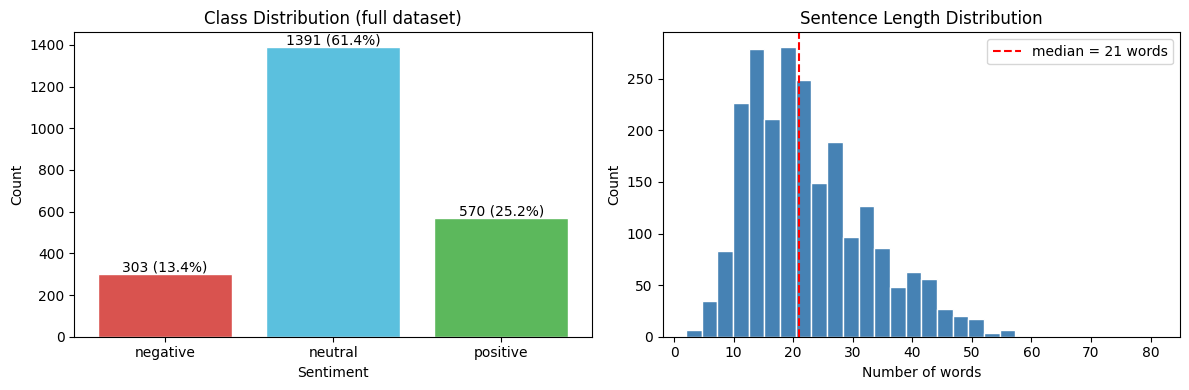

In [12]:
# Descriptive statistics and plots  # agllm
full = pd.concat([train, val, test], ignore_index=True)
full['n_words'] = full['text'].str.split().map(len)

print('=== Class distribution (full dataset, 2264 sentences) ===')
vc = full['label_name'].value_counts().reindex(['negative', 'neutral', 'positive'])
print(vc.to_string())
print()
print('Proportions:')
print((vc / vc.sum()).round(4).to_string())

print('\n=== Sentence length statistics ===')
print(full['n_words'].describe().round(2).to_string())

print('\n=== Per-split class counts ===')
for split_name, df in [('train', train), ('val', val), ('test', test)]:
    c = df['label_name'].value_counts().reindex(['negative', 'neutral', 'positive']).to_dict()
    print(f'  {split_name:12s}: {c}')

# ---- Plots ----
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

colors = ['#d9534f', '#5bc0de', '#5cb85c']
bars = axes[0].bar(vc.index, vc.values, color=colors, edgecolor='white')
axes[0].set_title('Class Distribution (full dataset)')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for bar, cnt in zip(bars, vc.values):
    pct = cnt / vc.sum()
    lbl = f'{cnt} ({pct:.1%})'
    axes[0].text(bar.get_x() + bar.get_width() / 2,
                 bar.get_height() + 12, lbl, ha='center', fontsize=10)

axes[1].hist(full['n_words'], bins=30, color='steelblue', edgecolor='white')
axes[1].axvline(full['n_words'].median(), color='red', linestyle='--',
                label=f"median = {int(full['n_words'].median())} words")
axes[1].set_title('Sentence Length Distribution')
axes[1].set_xlabel('Number of words')
axes[1].set_ylabel('Count')
axes[1].legend()

plt.tight_layout()
plt.show()

## 1c. Random Classifier Performance

i use a prior weighted random classifier as a simple baseline. this model does not read the text. it only guesses labels based on the class distribution in the training set. i use it to set a lower reference point. And the prior weighted random classifier uses the class distribution from the training set. it predicts neutral more often because neutral is the largest class. for the test set, it gets 0.4525 accuracy and 0.3282 macro F1. the accuracy is relatively higher because the model guesses the majority class more often, but the macro F1 is still low. this happens because the prior weighted model does not really learn the sentence meaning. it mostly benefits from the large neutral class. a useful classifier should clearly beat this random baseline, especially on macro F1.

In [13]:
# Prior-weighted random classifier (best random baseline)  # agllm
y_test = test['label'].to_numpy()
priors = train['label'].value_counts(normalize=True).sort_index().to_numpy()
print(f'Training class priors: neg={priors[0]:.3f}, neu={priors[1]:.3f}, pos={priors[2]:.3f}')

rng = np.random.default_rng(SEED)
y_random = rng.choice([0, 1, 2], size=len(y_test), p=priors)

print('\nPrior-weighted random classifier:')
m_r = eu.evaluate(y_test, y_random)
for k, v in m_r.items():
    print(f'  {k}: {v:.4f}')

eu.log_result('random-prior', 'baseline', 0, m_r, person=PERSON)

Training class priors: neg=0.134, neu=0.614, pos=0.252

Prior-weighted random classifier:
  accuracy: 0.4525
  f1_macro: 0.3282
  f1_weighted: 0.4540
  f1_negative: 0.1077
  f1_neutral: 0.6043
  f1_positive: 0.2727


,person,model,method,split,n_train_labeled,accuracy,f1_macro,f1_weighted,f1_negative,f1_neutral,f1_positive,notes
0,A,random-uniform,baseline,test,0,0.353201,0.323247,0.380071,0.195122,0.438799,0.335821,NaN
1,A,random-prior,baseline,test,0,0.465784,0.331857,0.464656,0.125984,0.632143,0.237443,NaN
2,A,rule-based,baseline,test,0,0.812362,0.735504,0.803389,0.588235,0.875421,0.742857,expanded-lexicon
3,B,bert-base-uncased,32-shot,test,32,0.679912,0.601195,0.697692,0.465116,0.823762,0.514706,val_f1_macro=0.5077
4,B,bert-base-uncased,full-1%,test,15,0.379691,0.283901,0.369218,0.027027,0.436548,0.388128,frac=0.01; epochs=3; maxlen=64
5,B,bert-base-uncased,full-10%,test,158,0.763797,0.505413,0.713277,0.000000,0.916239,0.600000,frac=0.1; epochs=3; maxlen=64
6,B,bert-base-uncased,full-25%,test,396,0.792494,0.533047,0.743541,0.000000,0.942207,0.656934,frac=0.25; epochs=3; maxlen=64
7,B,bert-base-uncased,full-50%,test,792,0.951435,0.936930,0.951398,0.930233,0.974729,0.905830,frac=0.5; epochs=3; maxlen=64
8,B,bert-base-uncased,full-75%,test,1188,0.962472,0.946171,0.962443,0.929134,0.985612,0.923767,frac=0.75; epochs=3; maxlen=64
9,B,bert-base-uncased,full-100%,test,1584,0.973510,0.958730,0.973657,0.936508,0.992780,0.946903,frac=1.0; epochs=3; maxlen=64


## 1d. Rule-Based Baseline

I build a simple rule based classifier with financial keywords. The method counts positive words and negative words in each sentence. Positive words include words like "profit", "growth", "rose", and "improved". Negative words include words like "loss", "decline", "fell", and "weak". if a sentence has more positive words, the model predicts positive. if a sentence has more negative words, the model predicts negative. if the counts are tied, the model predicts neutral. and i  chose this method because it is easy to understand. it also gives a stronger baseline than random guessing. the method uses financial words, so it is closer to the real task than a random classifier.

The rule based classifier performs much better than the random baselines. for  the test set, it gets 0.8124 accuracy and 0.7355 macro F1. this shows that many sentences in the allagree dataset contain clear sentiment words. the model also does well on neutral sentences, with a neutral F1 of 0.8754. and the main weakness is that the method does not understand context. it can make mistakes with negation, such as "no profit growth". it can also misunderstand words that depend on the situation. For example, "cut" can  negative in some cases, but an interest rate cut can be positive for markets. The negative class is still the weakest class here, with an F1 of 0.5882. this suggests that negative financial sentiment is harder to capture with keywords only.

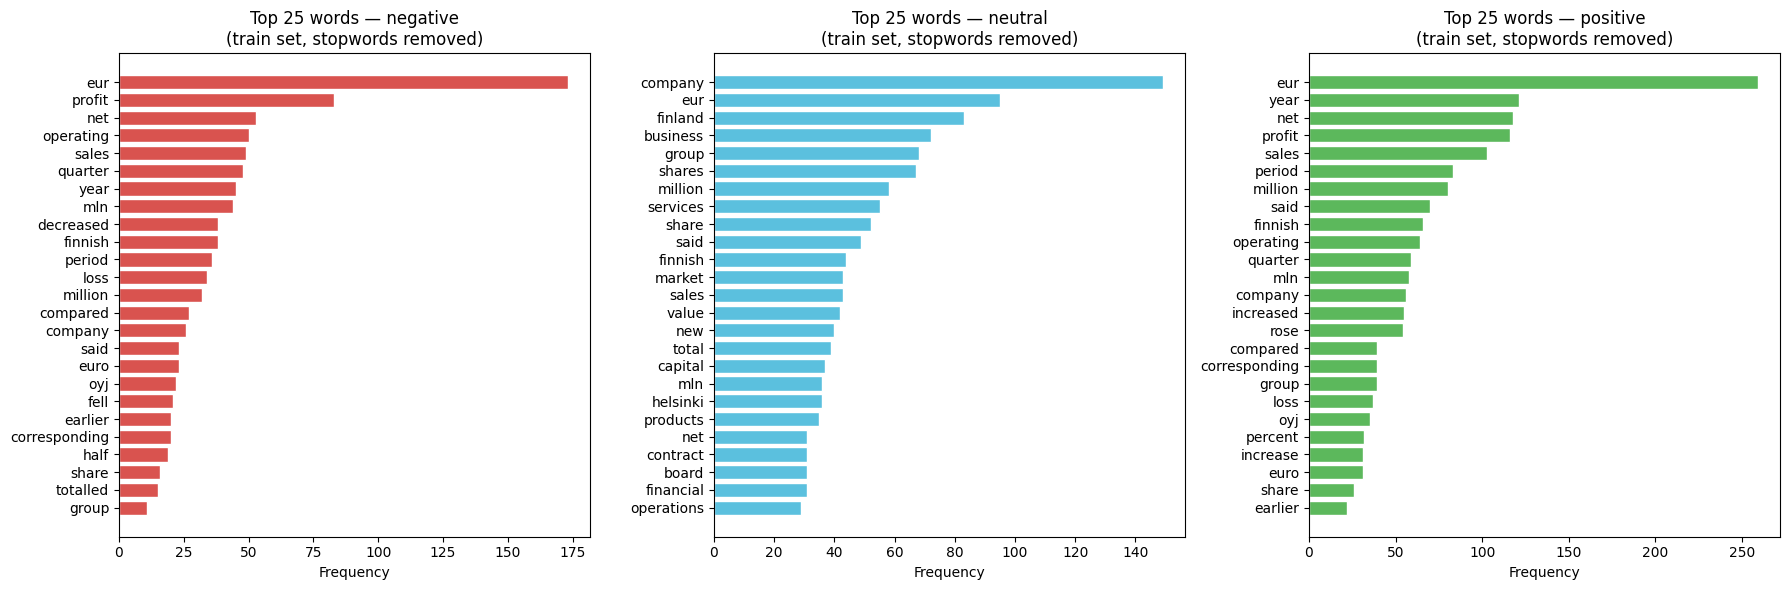

Top 15 negative words: ['eur', 'profit', 'net', 'operating', 'sales', 'quarter', 'year', 'mln', 'decreased', 'finnish', 'period', 'loss', 'million', 'compared', 'company']
Top 15 neutral  words: ['company', 'eur', 'finland', 'business', 'group', 'shares', 'million', 'services', 'share', 'said', 'finnish', 'market', 'sales', 'value', 'new']
Top 15 positive words: ['eur', 'year', 'net', 'profit', 'sales', 'period', 'million', 'said', 'finnish', 'operating', 'quarter', 'mln', 'company', 'increased', 'rose']


In [14]:
# EDA: top word frequencies per class (stopwords removed)  # agllm
from collections import Counter
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
import re

def top_words(df, label_name, top_n=25):
    tokens_all = []
    for text in df[df['label_name'] == label_name]['text']:
        tokens = re.findall(r'\b[a-z]+\b', text.lower())
        tokens = [w for w in tokens if w not in ENGLISH_STOP_WORDS and len(w) > 2]
        tokens_all.extend(tokens)
    return Counter(tokens_all).most_common(top_n)

neg_top = top_words(train, 'negative')
neu_top = top_words(train, 'neutral')
pos_top = top_words(train, 'positive')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for ax, (top, label, color) in zip(axes, [
    (neg_top, 'negative', '#d9534f'),
    (neu_top, 'neutral',  '#5bc0de'),
    (pos_top, 'positive', '#5cb85c'),
]):
    words, counts = zip(*top)
    ax.barh(list(words)[::-1], list(counts)[::-1], color=color, edgecolor='white')
    ax.set_title(f'Top 25 words — {label}\n(train set, stopwords removed)')
    ax.set_xlabel('Frequency')

plt.tight_layout()
plt.show()

print('Top 15 negative words:', [w for w, _ in neg_top[:15]])
print('Top 15 neutral  words:', [w for w, _ in neu_top[:15]])
print('Top 15 positive words:', [w for w, _ in pos_top[:15]])

### EDA Findings

for the  word frequency charts, some words like "eur", "profit", "sales", and "net" appear in all three classes.‍ these words are common in financial sentences in general, so they are not useful for telling the classes apart.‍and the neutral class is dominated by words like "company", "group", "business", and "shares".‍ these are mostly names or organizational words with no clear positive or negative direction.‍ also the words actually separate negative from positive are the directional words.‍ "decreased" and "loss" show up more in negative sentences, while "increased" and "rose" appear more in positive ones.‍ this is why i built the lexicon around these kinds of action words rather than financial nouns like "profit" or "sales".‍

Rule-based classifier on test set:
  accuracy: 0.8124
  f1_macro: 0.7355
  f1_weighted: 0.8034
  f1_negative: 0.5882
  f1_neutral: 0.8754
  f1_positive: 0.7429


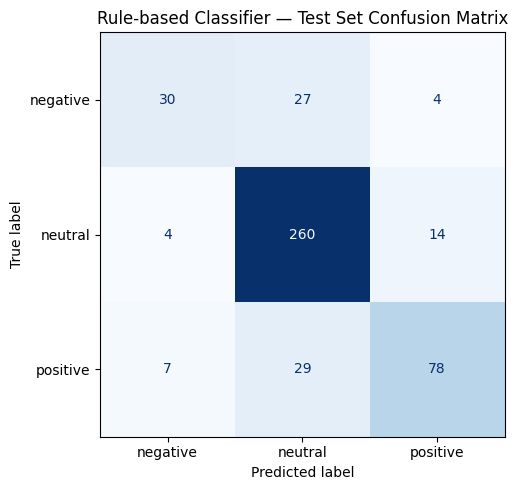

=== Correct predictions (sample) ===

[TRUE: NEGATIVE | PREDICTED: NEGATIVE] ✓
  Acando AB ( ACANB SS ) fell 8.9 percent to 13.35 kronor , the lowest close since Dec. 11 .

[TRUE: NEUTRAL | PREDICTED: NEUTRAL] ✓
  The board machine , which will have a wire width of 6.25 m and a design speed of 900 m-min , will produce close to 1,400 tonnes of folding boxboard per day .

[TRUE: POSITIVE | PREDICTED: POSITIVE] ✓
  In January , traffic , measured in revenue passenger kilometres RPK , went up by 3.2 % and capacity , measured in available seat kilometres ASK , rose by 12.2 % .

=== Wrong predictions (sample) ===

[TRUE: NEGATIVE | PREDICTED: NEUTRAL] ✗
  Operating loss totaled EUR 25mn compared to a profit of EUR 63mn in the corresponding period in 2005 .

[TRUE: NEUTRAL | PREDICTED: POSITIVE] ✗
  The Swedish subsidiary holds 1.0 % net smelter return `` NSR '' royalties over two advanced copper projects in northern Sweden - the Viscaria and Adak Projects - being developed by Avalon Minerals

In [15]:
# Expanded financial sentiment lexicon  # agllm
POS_WORDS = {
    'increase', 'increased', 'increases', 'increasing',
    'rose', 'rise', 'risen', 'rising',
    'growth', 'grew', 'grow', 'growing',
    'profit', 'profitable', 'profitability', 'profitably',
    'gain', 'gains', 'gained',
    'higher',
    'improved', 'improve', 'improvement', 'improving',
    'strong', 'stronger', 'strength',
    'up', 'upward',
    'better', 'best', 'positive',
    'record', 'exceed', 'exceeded', 'exceeds', 'exceeding',
    'surpass', 'surpassed', 'surpassing',
    'expand', 'expanded', 'expanding', 'expansion',
    'recovery', 'recover', 'recovered', 'recovering',
    'success', 'successful', 'successfully',
    'win', 'won',
    'boost', 'boosted', 'boosting',
    'advance', 'advanced', 'advancing',
    'outperform', 'outperformed', 'outperforms',
    'rebound', 'rebounded', 'rebounding',
    'jump', 'jumped', 'jumps',
    'surge', 'surged', 'surging',
    'soar', 'soared', 'soaring',
    'accelerate', 'accelerated', 'acceleration',
    'climb', 'climbed', 'climbing',
}

NEG_WORDS = {
    'decrease', 'decreased', 'decreases', 'decreasing',
    'fell', 'fall', 'fallen', 'falling',
    'loss', 'losses',
    'down', 'downward',
    'lower',
    'decline', 'declined', 'declines', 'declining',
    'weak', 'weaker', 'weakness', 'weakened', 'weakening',
    'cut', 'cuts', 'cutting',
    'drop', 'dropped', 'drops', 'dropping',
    'negative', 'worse', 'worst', 'worsen', 'worsened', 'worsening',
    'miss', 'missed',
    'shrink', 'shrank', 'shrunk', 'shrinking',
    'layoff', 'layoffs', 'restructuring', 'restructured',
    'downturn', 'slowdown',
    'concern', 'concerns', 'uncertain', 'uncertainty',
    'problem', 'problems', 'difficult', 'difficulty', 'difficulties',
    'fail', 'failed', 'failure', 'failing',
    'bankrupt', 'bankruptcy',
    'impairment', 'impaired',
    'suspend', 'suspended', 'suspension',
    'deteriorate', 'deteriorated', 'deteriorating', 'deterioration',
    'slump', 'slumped', 'slumping',
    'plunge', 'plunged', 'plunging',
    'warn', 'warned', 'warnings',
    'deficit',
}


def rule_predict(text):
    tokens = text.lower().replace(',', ' ').replace('.', ' ').split()
    p = sum(w in POS_WORDS for w in tokens)
    n = sum(w in NEG_WORDS for w in tokens)
    if p > n:
        return 2
    elif n > p:
        return 0
    return 1  # default neutral when tied or no keyword found


y_pred = test['text'].map(rule_predict).to_numpy()
m = eu.evaluate(y_test, y_pred)
print('Rule-based classifier on test set:')
for k, v in m.items():
    print(f'  {k}: {v:.4f}')

eu.log_result('rule-based', 'baseline', 0, m, person=PERSON, notes='expanded-lexicon')

# Confusion matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['negative', 'neutral', 'positive'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('Rule-based Classifier — Test Set Confusion Matrix')
plt.tight_layout()
plt.show()

# --- Example sentences: correct and incorrect predictions ---
pred_df = test.copy()
pred_df['predicted'] = y_pred
pred_df['pred_name'] = pred_df['predicted'].map({0: 'negative', 1: 'neutral', 2: 'positive'})
pred_df['correct'] = pred_df['label'] == pred_df['predicted']

print('=== Correct predictions (sample) ===')
for lbl in ['negative', 'neutral', 'positive']:
    subset = pred_df[(pred_df['label_name'] == lbl) & pred_df['correct']]
    if len(subset):
        row = subset.sample(1, random_state=SEED).iloc[0]
        print(f'\n[TRUE: {lbl.upper()} | PREDICTED: {row["pred_name"].upper()}] ✓')
        print(f'  {row["text"]}')

print('\n=== Wrong predictions (sample) ===')
for lbl in ['negative', 'neutral', 'positive']:
    subset = pred_df[(pred_df['label_name'] == lbl) & ~pred_df['correct']]
    if len(subset):
        row = subset.sample(1, random_state=SEED).iloc[0]
        print(f'\n[TRUE: {lbl.upper()} | PREDICTED: {row["pred_name"].upper()}] ✗')
        print(f'  {row["text"]}')